In [1]:
import pandas as pd
df_1 = pd.read_csv('api_data_aadhar_enrolment_0_500000.csv')
df_2 = pd.read_csv('api_data_aadhar_enrolment_1000000_1006029.csv')
df_3 = pd.read_csv('api_data_aadhar_enrolment_500000_1000000.csv')

combined_df = pd.concat([df_1, df_2, df_3], ignore_index=True)

print("Shape of combined_df:", combined_df.shape)
print("First 5 rows of combined_df:")
print(combined_df.head())

Shape of combined_df: (1006029, 7)
First 5 rows of combined_df:
         date          state          district  pincode  age_0_5  age_5_17  \
0  02-03-2025      Meghalaya  East Khasi Hills   793121       11        61   
1  09-03-2025      Karnataka   Bengaluru Urban   560043       14        33   
2  09-03-2025  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3  09-03-2025  Uttar Pradesh           Aligarh   202133       62        29   
4  09-03-2025      Karnataka   Bengaluru Urban   560016       14        16   

   age_18_greater  
0              37  
1              39  
2              12  
3              15  
4              21  


In [2]:

   # total_enrollement

combined_df['total_enrollement'] = combined_df['age_0_5'] + combined_df['age_5_17'] + combined_df['age_18_greater']
display(combined_df.head())

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrollement
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37,109
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39,86
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15,106
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21,51


In [3]:
combined_df =combined_df[combined_df.pincode!=100000]

In [4]:
combined_df['state'] = combined_df['state'].str.strip()
combined_df['state'] = combined_df['state'].str.title()

state_name_mapping = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands',
    'Andaman And Nicobar Islands': 'Andaman and Nicobar Islands',
    'Orissa': 'Odisha',
    'Pondicherry': 'Puducherry',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Jammu And Kashmir': 'Jammu and Kashmir',
    'West  Bengal': 'West Bengal',
    'West Bangal': 'West Bengal',
    'West Bengal': 'West Bengal',
    'Westbengal': 'West Bengal',
    'Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'The Dadra And Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'The Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Nct Of Delhi': 'Delhi'
}

combined_df['state'] = combined_df['state'].replace(state_name_mapping)

print(combined_df.head())

         date          state          district  pincode  age_0_5  age_5_17  \
0  02-03-2025      Meghalaya  East Khasi Hills   793121       11        61   
1  09-03-2025      Karnataka   Bengaluru Urban   560043       14        33   
2  09-03-2025  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3  09-03-2025  Uttar Pradesh           Aligarh   202133       62        29   
4  09-03-2025      Karnataka   Bengaluru Urban   560016       14        16   

   age_18_greater  total_enrollement  
0              37                109  
1              39                 86  
2              12                123  
3              15                106  
4              21                 51  


In [5]:
print("Total States : ",len(combined_df['state'].value_counts()))
print(combined_df['state'].value_counts())

Total States :  36
state
Uttar Pradesh                               110369
Tamil Nadu                                   92552
Maharashtra                                  77191
West Bengal                                  76561
Karnataka                                    70198
Andhra Pradesh                               65663
Bihar                                        60567
Rajasthan                                    56159
Madhya Pradesh                               50225
Odisha                                       47011
Gujarat                                      46624
Telangana                                    42774
Kerala                                       39145
Assam                                        31827
Jharkhand                                    23218
Punjab                                       20439
Chhattisgarh                                 18550
Haryana                                      15997
Jammu and Kashmir                            11455
Himach

In [6]:
district_name_mapping = {
    'Kushinagar *': 'Kushinagar', 'Siddharth Nagar': 'Siddharthnagar','Bagpat': 'Baghpat', 'Bulandshahar': 'Bulandshahr', 'Sant Ravidas Nagar': 'Bhadohi','Bara Banki': 'Barabanki','Raebareli': 'Rae Bareli',
    'Sant Ravidas Nagar Bhadohi': 'Sant Ravidas Nagar','Ambedkar Nagar': 'Ambedkar Nagar','Prayagraj': 'Allahabad', 'Faizabad': 'Ayodhya', 'Jyotiba Phule Nagar': 'Amroha','Kushi Nagar': 'Kushinagar',
    'Maharajganj': 'Mahrajganj','Shravasti': 'Shrawasti','Kanpur Nagar': 'Kanpur Urban','Kanpur Nagr': 'Kanpur Urban','Aurangabad(bh)': 'Aurangabad','Aurangabad(BH)': 'Aurangabad','Bangalore Urban': 'Bengaluru Urban',
    'Mumbai City': 'Mumbai Suburban','Kanchipuram': 'Kancheepuram','Kanyakumari': 'Kanniyakumari','Namakkal   *': 'Namakkal','Thiruvallur': 'Tiruvallur','Tirupathur': 'Tirupattur','Thiruvarur': 'Tiruvarur',
    'Tuticorin': 'Thoothukkudi','Villupuram': 'Viluppuram','Ahmadnagar': 'Ahilyanagar','Ahmed Nagar': 'Ahilyanagar','Ahmednagar': 'Ahilyanagar','Bid': 'Beed','Buldana': 'Buldhana',
    'Aurangabad': 'Chhatrapati Sambhajinagar','Chatrapati Sambhaji Nagar': 'Chhatrapati Sambhajinagar','Gondiya': 'Gondia','Gondiya *': 'Gondia','Hingoli *': 'Hingoli','Mumbai( Sub Urban )': 'Mumbai Suburban',
    'Nandurbar *': 'Nandurbar','Osmanabad': 'Dharashiv','Raigarh(Mh)': 'Raigad','Washim *': 'Washim',"24 Paraganas North": "North 24 Parganas","North Twenty Four Parganas": "North 24 Parganas",
    "24 Paraganas South": "South 24 Parganas","South 24 Pargana": "South 24 Parganas","South Twenty Four Parganas": "South 24 Parganas","Cooch Behar": "Coochbehar","Koch Bihar": "Coochbehar","Darjiling": "Darjeeling",
    "Dinajpur Dakshin": "Dakshin Dinajpur","South Dinajpur": "Dakshin Dinajpur","Dinajpur Uttar": "Uttar Dinajpur","North Dinajpur": "Uttar Dinajpur","East Midnapore": "Purba Medinipur","East Midnapur": "Purba Medinipur",
    "West Medinipur": "Paschim Medinipur","West Midnapore": "Paschim Medinipur","Medinipur West": "Paschim Medinipur","Medinipur": "Paschim Medinipur","Haora": "Howrah","Hawrah": "Howrah","Hooghiy": "Hooghly",
    "Hugli": "Hooghly","Maldah": "Malda","Puruliya": "Purulia","Barddhaman": "Purba Bardhaman","Bardhaman": "Purba Bardhaman","Burdwan": "Purba Bardhaman",'Ananthapur': 'Anantapur','Ananthapuramu': 'Anantapur',
    'Cuddapah': 'Y.S.R. Kadapa','K.V. Rangareddy': 'Ranga Reddy','K.V.Rangareddy': 'Ranga Reddy','Rangareddi': 'Ranga Reddy','Karim Nagar': 'Karimnagar','Khammam': 'Khammam','Mahabub Nagar': 'Mahabubnagar',
    'Mahbubnagar': 'Mahabubnagar','Spsr Nellore': 'Nellore','Sri Potti Sriramulu Nellore': 'Nellore','Visakhapatanam': 'Visakhapatnam','Y. S. R': 'Y.S.R. Kadapa','N. T. R': 'N.T.R.','North Delhi': 'North Delhi',
    'South Delhi': 'South Delhi','East Delhi': 'East Delhi','West Delhi': 'West Delhi','North East Delhi': 'North East','North West Delhi': 'North West','South West Delhi': 'South West Delhi',
    'Central Delhi': 'Central Delhi','Shahdara': 'Shahdara','North East   *': 'North East','Najafgarh': 'South West Delhi'
}

district_name_mapping.update({
     "Jagitial": "Jagtial","Jangoan": "Jangaon","Rangareddy": "Ranga Reddy","Medchal Malkajgiri": "Medchal–Malkajgiri","Medchal-Malkajgiri": "Medchal–Malkajgiri","Medchal?Malkajgiri": "Medchal–Malkajgiri",
     "Medchal−Malkajgiri": "Medchal–Malkajgiri","Warangal (Urban)": "Warangal","Warangal Urban": "Warangal","Warangal Rural": "Warangal",
    "Yadadri.": "Yadadri Bhuvanagiri",'Anugal': 'Angul','Anugul':	'Angul','Baleshwar': 'Balasore','Baleswar': 'Balasore','Baudh':	'Boudh','Debagarh':	'Deogarh','Jagatsinghapur':	'Jagatsinghpur','Jajapur':	'Jajpur',
'Kendrapara *':	'Kendrapara','Khorda':	'Khordha','Nabarangapur':	'Nabarangpur','Sonapur':	'Subarnapur','Sundergarh':	'Sundargarh','Kasargod'	:'Kasaragod',"Ramanagar": "Ramanagara","Tumkur": "Tumakuru",
    "Bijapur": "Bijapur", "Bangalore": "Bengaluru Urban","Bengaluru": "Bengaluru Urban","Bengaluru South": "Bengaluru Urban","Bangalore Rural": "Bengaluru Rural","Bellary": "Ballari","Belgaum": "Belagavi",
    "Gulbarga": "Kalaburagi","Shimoga": "Shivamogga","Mysore": "Mysuru","Tumkur": "Tumakuru","Ramanagar": "Ramanagara","Bijapur(KAR)": "Vijayapura","Bijapur(Kar)": "Vijayapura","Chickmagalur": "Chikkamagaluru",
     "Chikmagalur": "Chikkamagaluru","Chikballapur": "Chikkaballapur","Davanagere": "Davangere","Hasan": "Hassan","Chamrajanagar": "Chamarajanagar","Chamrajnagar": "Chamarajanagar","Bagalkot *": "Bagalkot",
    "Chamarajanagar *": "Chamarajanagar","Gadag *": "Gadag","Haveri *": "Haveri","Udupi *": "Udupi",'Baroda': 'Vadodara','Panchmahals': 'Panchmahal','Sabarkantha': 'Sabarkantha','Kutch': 'Kachchh',
'Kachchh': 'Kachchh',"Ahmadabad": "Ahmedabad","Arvalli": "Aravalli","Banas Kantha": "Banaskantha","Dohad": "Dahod","Panch Mahals": "Panchmahal","Sabar Kantha": "Sabarkantha","Surendra Nagar": "Surendranagar",
"Chhotaudepur": "Chhota Udaipur","The Dangs": "Dang",'Dungarpur *': 'Dungarpur','Churu *': 'Churu','Sawai Madhopur *': 'Sawai Madhopur','Jodhpur *': 'Jodhpur','Jaipur *': 'Jaipur','Jhunjhunun': 'Jhunjhunu',
    'Chittaurgarh': 'Chittorgarh', "Dhaulpur": "Dholpur","Jalor": "Jalore","Didwana-Kuchaman": "Didwana–Kuchaman",'Hoshangabad': 'Narmadapuram','Sehore *': 'Sehore','Shahdol *': 'Shahdol','Sidhi *': 'Sidhi',
'Ashoknagar': 'Ashok Nagar','Harda *': 'Harda','East Nimar': 'Khandwa','West Nimar': 'Khargone','Narsimhapur': 'Narsinghpur','Kanker': 'Uttar Bastar Kanker','Bastar': 'Bastar','Dantewada': 'Dakshin Bastar Dantewada',
    "Baloda Bazar": "Baloda Bazar–Bhatapara","Balrampur": "Balrampur–Ramanujganj","Gaurella Pendra Marwahi": "Gaurela–Pendra–Marwahi","Janjgir - Champa": "Janjgir–Champa","Janjgir Champa": "Janjgir–Champa",
"Janjgir-Champa": "Janjgir–Champa","Kabeerdham": "Kabirdham","Kawardha": "Kabirdham","Raigad": "Raigarh","Raigarh": "Raigad", "Mohalla-Manpur-Ambagarh Chowki": "Mohla–Manpur–Ambagarh Chowki",
  "Mohla-Manpur-Ambagarh Chouki": "Mohla–Manpur–Ambagarh Chowki","Gaurela-Pendra-Marwahi": "Gaurela–Pendra–Marwahi","Sarangarh-Bilaigarh": "Sarangarh–Bilaigarh",
"Khairagarh Chhuikhadan Gandai": "Khairagarh–Chhuikhadan–Gandai","Vijayapura": "Bijapur",'Balasore': 'Baleshwar','Bargarh *': 'Bargarh','Jagatsinghpur': 'Jagatsinghpur','Kendrapara': 'Kendrapara',"Purnea": "Purnia",
"Buxer": "Buxar", "Lakhisaray": "Lakhisarai","Samstipur": "Samastipur","Sheikpura": "Sheikhpura","Monghyr": "Munger","Purbi Champaran": "East Champaran","Purba Champaran": "East Champaran",
"Paschim Champaran": "West Champaran","Pashchim Champaran": "West Champaran", "Kaimur (Bhabua)": "Kaimur", "Bhabua": "Kaimur","Aurangabad(Bh)": "Aurangabad",'Hazaribagh *': 'Hazaribagh','Singhbhum East': 'East Singhbhum',
'Singhbhum West': 'West Singhbhum',"Bokaro *": "Bokaro","Garhwa *": "Garhwa","East Singhbum": "East Singhbhum","Hazaribag": "Hazaribagh","Kodarma": "Koderma","Pakaur": "Pakur","Palamau": "Palamu",
"Pashchimi Singhbhum": "West Singhbhum","Purbi Singhbhum": "East Singhbhum","Sahebganj": "Sahibganj", "Dadra And Nagar Haveli": "Dadra and Nagar Haveli","Dadra & Nagar Haveli": "Dadra and Nagar Haveli",
'Ferozepur': 'Firozpur','Muktsar': 'Sri Muktsar Sahib','Nawanshahr': 'Shaheed Bhagat Singh Nagar','S.A.S Nagar': 'S.A.S Nagar(Mohali)','Sas Nagar (Mohali)': 'S.A.S Nagar(Mohali)','Gurgaon': 'Gurugram',
'Mewat': 'Nuh',"Jhajjar *": "Jhajjar","Yamuna Nagar": "Yamunanagar",'Hardwar': 'Haridwar','Udham Singh Nagar': 'Udham Singh Nagar',"Garhwal": "Pauri Garhwal",'Kargil': 'Kargil',"Badgam": "Budgam",
"Bandipore": "Bandipora","Bandipur": "Bandipora","Punch": "Poonch","Rajauri": "Rajouri","Shupiyan": "Shopian","Baramula": "Baramulla",'Leh (Ladakh)': 'Leh','Kamrup Metro': 'Ri Bhoi','Cachar *': 'Cachar',
'East': 'East Sikkim','West': 'West Sikkim','North': 'North Sikkim','South': 'South Sikkim',"North Cachar Hills": "Dima Hasao","Sibsagar": "Sivasagar","Marigaon": "Morigaon",
"South Salmara Mankachar": "South Salmara–Mankachar","Tamulpur District": "Tamulpur","Karimganj": "Sribhumi","Kamrup Metropolitan": "Ri Bhoi", 'Bardez': 'North Goa', "Andamans": "South Andaman",
"Nicobars": "Nicobar","Lahaul And Spiti": "Lahaul and Spiti","Lahul & Spiti": "Lahaul and Spiti","Lahul And Spiti": "Lahaul and Spiti","Kamrup": "Ri Bhoi","Jaintia Hills": "West Jaintia Hills",
  'Dhalai  *': 'Dhalai',"Pondicherry": "Puducherry","Mammit": "Mamit","Rupnagar": "Chandigarh",'N/A': None,'NA': None,'NULL': None,'': None
})

combined_df['district'] = combined_df['district'].astype(str).str.strip().str.title()
combined_df['district'] = combined_df['district'].replace(district_name_mapping)

telangana_districts = [
    'Adilabad', 'Bhadradri Kothagudem', 'Hyderabad', 'Jagtial', 'Jangaon','Jayashankar Bhupalpally', 'Jogulamba Gadwal', 'Kamareddy', 'Karimnagar','Khammam', 'Komaram Bheem', 'Mahabubabad', 'Mahabubnagar',
    'Mancherial','Medak', 'Medchal', 'Mulugu', 'Nagarkurnool', 'Nalgonda', 'Narayanpet','Nirmal', 'Nizamabad', 'Peddapalli', 'Rajanna Sircilla', 'Ranga Reddy','Sangareddy', 'Siddipet', 'Suryapet', 'Vikarabad',
    'Wanaparthy','Warangal', 'Yadadri Bhuvanagiri'
]

combined_df.loc[
    (combined_df['state'] == 'Andhra Pradesh') &
    (combined_df['district'].isin(telangana_districts)),
    'state'
] = 'Telangana'

combined_df.loc[combined_df['district'] == 'Raigarh', 'state'] = 'Chhattisgarh'

state_district_wise_total_enrolment = combined_df.groupby(['state','district'])['total_enrollement'].sum().reset_index()
state_wise_total_enrolment = combined_df.groupby('state')['total_enrollement'].sum().reset_index().sort_values('total_enrollement', ascending=False)

combined_df.loc[combined_df['district'] == 'Raigad', 'state'] = 'Maharashtra'

state_district_wise_total_enrolment = combined_df.groupby(['state','district'])['total_enrollement'].sum().reset_index()
state_wise_total_enrolment = combined_df.groupby('state')['total_enrollement'].sum().reset_index().sort_values('total_enrollement', ascending=False)


combined_df.loc[combined_df['district'] == 'Chhatrapati Sambhajinagar', 'state'] = 'Maharashtra'

state_district_wise_total_enrolment = combined_df.groupby(['state','district'])['total_enrollement'].sum().reset_index()
state_wise_total_enrolment = combined_df.groupby('state')['total_enrollement'].sum().reset_index().sort_values('total_enrollement', ascending=False)


state_district_wise_total_enrolment = combined_df.groupby(['state', 'district'])['total_enrollement'].sum().reset_index()
state_wise_total_enrolment = combined_df.groupby(['state'])['total_enrollement'].sum().reset_index().sort_values(by='total_enrollement', ascending=False)

In [7]:
pincodes_for_ladakh = [194101, 194201, 194401, 194106, 194104, 194404, 194102, 194105, 194103, 194109, 194403, 194301, 194302]

combined_df.loc[
    (combined_df['district'].isin(['Leh', 'Kargil'])) &
    (combined_df['pincode'].isin(pincodes_for_ladakh)),
    'state'
] = 'Ladakh'

state_district_wise_total_enrolment = combined_df.groupby(['state', 'district'])['total_enrollement'].sum().reset_index()
state_wise_total_enrolment = combined_df.groupby(['state'])['total_enrollement'].sum().reset_index().sort_values(by='total_enrollement', ascending=False)

print("Updated state assignments for Leh and Kargil districts to Ladakh where pincodes match the provided list.")
print("Re-calculated state_district_wise_total_enrolment and state_wise_total_enrolment.")

Updated state assignments for Leh and Kargil districts to Ladakh where pincodes match the provided list.
Re-calculated state_district_wise_total_enrolment and state_wise_total_enrolment.


In [8]:
state_wise_total_enrolment = combined_df.groupby(['state'])['total_enrollement'].sum().reset_index().sort_values(by='total_enrollement', ascending=False)
print("head : ")
print(state_wise_total_enrolment.head())

print()
print()
print("tail : ")
print(state_wise_total_enrolment.tail())

head : 
             state  total_enrollement
33   Uttar Pradesh            1018629
4            Bihar             599415
19  Madhya Pradesh             493970
20     Maharashtra             380832
35     West Bengal             375340


tail : 
                                       state  total_enrollement
29                                    Sikkim               2207
7   Dadra and Nagar Haveli and Daman and Diu               1799
17                                    Ladakh               1356
0                Andaman and Nicobar Islands                511
18                               Lakshadweep                203


In [9]:
state_district_wise_total_enrolment = combined_df.groupby(['state', 'district'])['total_enrollement'].sum().reset_index()
print(state_district_wise_total_enrolment.head())

                         state                  district  total_enrollement
0  Andaman and Nicobar Islands                   Nicobar                 76
1  Andaman and Nicobar Islands  North And Middle Andaman                132
2  Andaman and Nicobar Islands             South Andaman                303
3               Andhra Pradesh     Alluri Sitharama Raju               1255
4               Andhra Pradesh                Anakapalli                543


In [10]:
total_peope_of_age= combined_df.groupby(['state'])['total_enrollement'].sum()
count1= combined_df.groupby(['state'])['total_enrollement'].count()

In [11]:
avg_people_of_total_people= total_peope_of_age/count1
avg_people_of_total_people.sort_values(ascending=False, inplace=True)

C:\Users\kshit\AppData\Local\Temp\ipykernel_9000\3806307764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


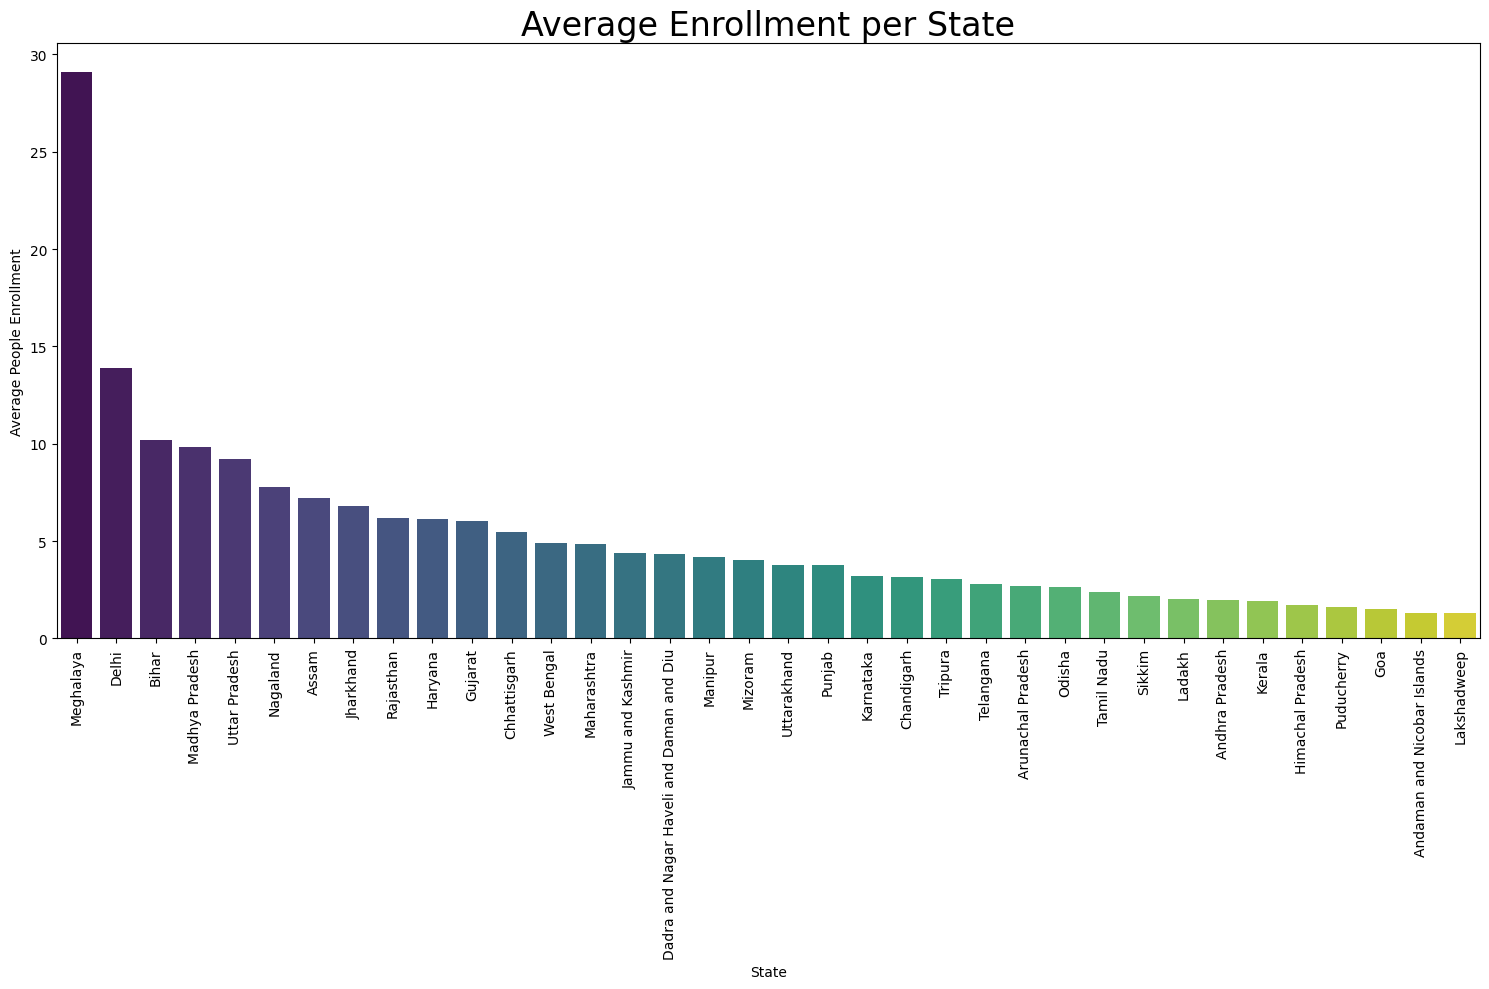

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.barplot(
    x=avg_people_of_total_people.index,
    y=avg_people_of_total_people.values,
    palette="viridis"
)
plt.title('Average Enrollment per State', fontsize=24)
plt.xlabel("State")
plt.ylabel("Average People Enrollment")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Enter state name Maharashtra


C:\Users\kshit\AppData\Local\Temp\ipykernel_9000\3148140117.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


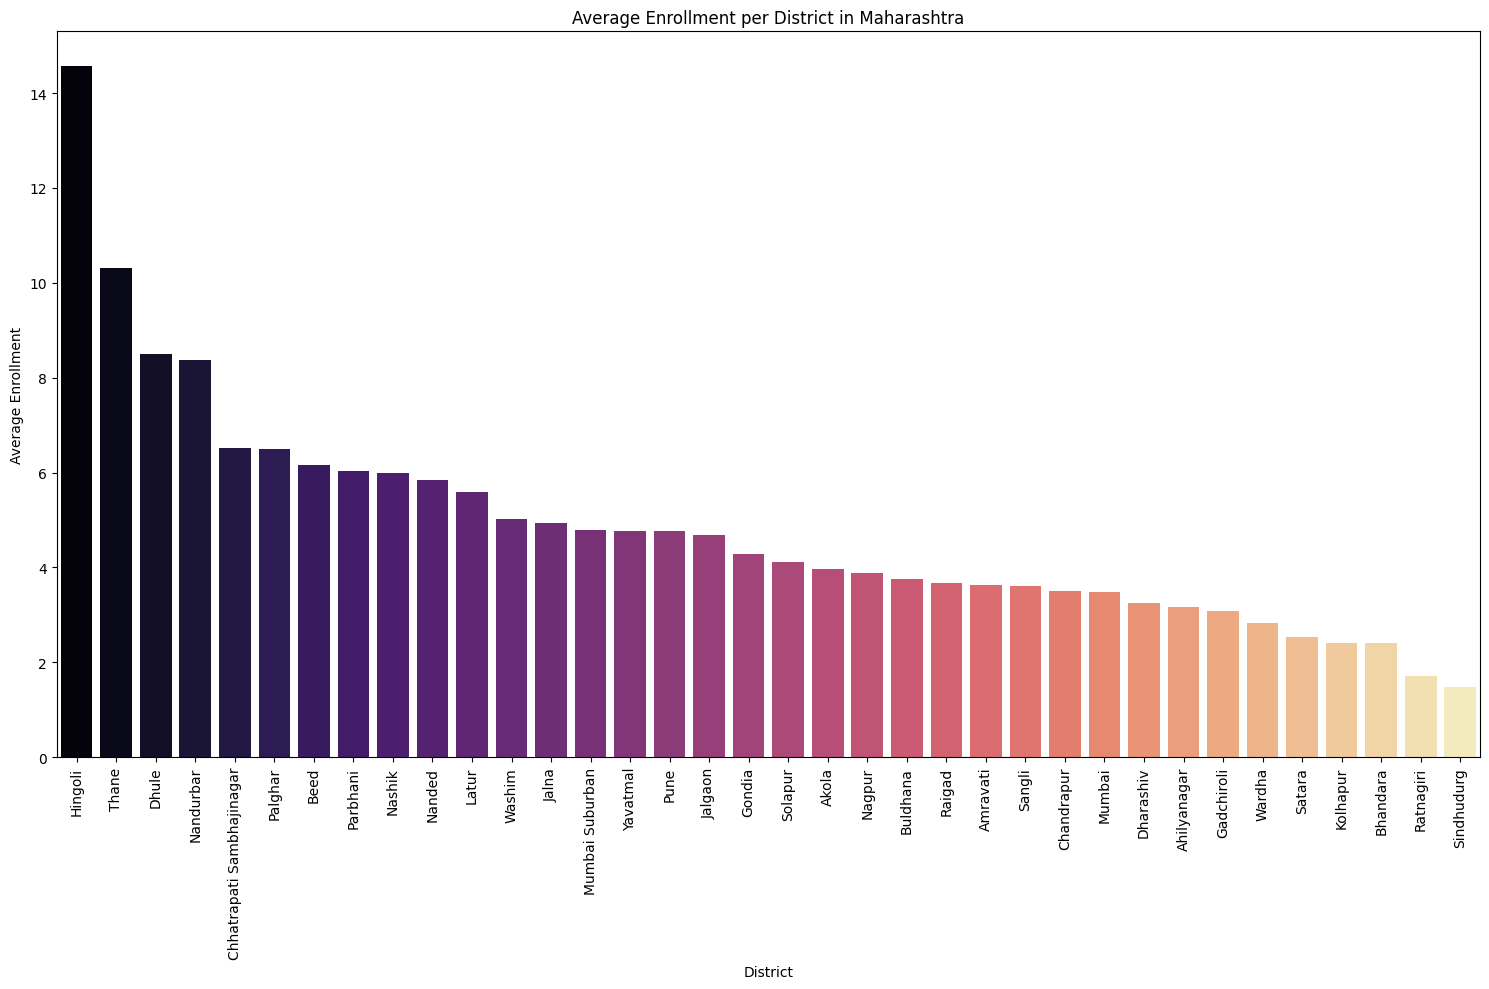

In [14]:
state_name = input('Enter state name')

state_df = combined_df[combined_df['state'] == state_name]

total_people_district = state_df.groupby('district')['total_enrollement'].sum()
count = state_df.groupby('district')['total_enrollement'].count()
total_people_each_day = total_people_district / count

total_people_each_day = total_people_each_day.sort_values(ascending=False)

plt.figure(figsize=(15, 10))

sns.barplot(
    x=total_people_each_day.index,
    y=total_people_each_day.values,
    palette="magma"
)

plt.xticks(rotation=90)   # rotate district names
plt.xlabel('District')
plt.ylabel('Average Enrollment')
plt.title(f'Average Enrollment per District in {state_name}')

plt.tight_layout()
plt.show()


In [15]:
total_peope_all_days = combined_df.groupby(['state'])['total_enrollement'].sum()
count = combined_df.groupby(['state'])['total_enrollement'].count()

In [16]:
avg_people_each_state = total_peope_all_days/count

In [17]:
print(avg_people_each_state.name)

total_enrollement


In [18]:
import numpy as np
import pandas as pd

In [19]:
import geopandas as gpd
from pyogrio import set_gdal_config_options
set_gdal_config_options({
    'SHAPE_RESTORE_SHX': 'YES',
})

In [20]:
fp = r'india-polygon.shp'
map_df = gpd.read_file(fp)
map_df_copy = gpd.read_file(fp)
map_df.head()

,id,st_nm,geometry
0,None,Andaman and Nicobar Islands,"MULTIPOLYGON (((93.84831 7.24028, 93.92705 7.0..."
1,None,Arunachal Pradesh,"POLYGON ((95.23643 26.68105, 95.19594 27.03612..."
2,None,Assam,"POLYGON ((95.19594 27.03612, 95.08795 26.94578..."
3,None,Bihar,"POLYGON ((88.11357 26.54028, 88.28006 26.3764,..."
4,None,Chandigarh,"POLYGON ((76.84208 30.76124, 76.83758 30.72552..."


In [21]:
map_df['st_nm']

0     Andaman and Nicobar Islands
1               Arunachal Pradesh
2                           Assam
3                           Bihar
4                      Chandigarh
5                    Chhattisgarh
6          Dadra and Nagar Haveli
7                   Daman and Diu
8                             Goa
9                         Gujarat
10                        Haryana
11               Himachal Pradesh
12                      Jharkhand
13                      Karnataka
14                         Kerala
15                    Lakshadweep
16                 Madhya Pradesh
17                    Maharashtra
18                        Manipur
19                      Meghalaya
20                        Mizoram
21                       Nagaland
22                          Delhi
23                     Puducherry
24                         Punjab
25                      Rajasthan
26                         Sikkim
27                     Tamil Nadu
28                      Telangana
29            

In [22]:
df = pd.read_csv('downloaded_Enrollment_Combined_data.csv')

In [23]:
total_peope_all_days = df.groupby(['state'])['total_enrollement'].sum()
count = df.groupby(['state'])['total_enrollement'].count()

In [24]:
avg_people_all_day = total_peope_all_days/count

In [25]:
merged = map_df.set_index('st_nm').join(avg_people_all_day)

In [26]:
merged

,id,geometry,total_enrollement
st_nm,,,
Andaman and Nicobar Islands,None,"MULTIPOLYGON (((93.84831 7.24028, 93.92705 7.0...",1.303571
Arunachal Pradesh,None,"POLYGON ((95.23643 26.68105, 95.19594 27.03612...",2.713304
Assam,None,"POLYGON ((95.19594 27.03612, 95.08795 26.94578...",7.232758
Bihar,None,"POLYGON ((88.11357 26.54028, 88.28006 26.3764,...",10.164572
Chandigarh,None,"POLYGON ((76.84208 30.76124, 76.83758 30.72552...",3.169965
Chhattisgarh,None,"POLYGON ((83.94694 23.62196, 83.95594 23.62406...",5.443529
Dadra and Nagar Haveli,None,"POLYGON ((73.2064 20.12165, 73.20865 20.10695,...",NaN
Daman and Diu,None,"POLYGON ((72.80144 20.37378, 72.84418 20.47463...",NaN
Goa,None,"POLYGON ((74.11982 15.65278, 74.24806 15.65698...",1.527832


In [27]:
import matplotlib.pyplot as plt

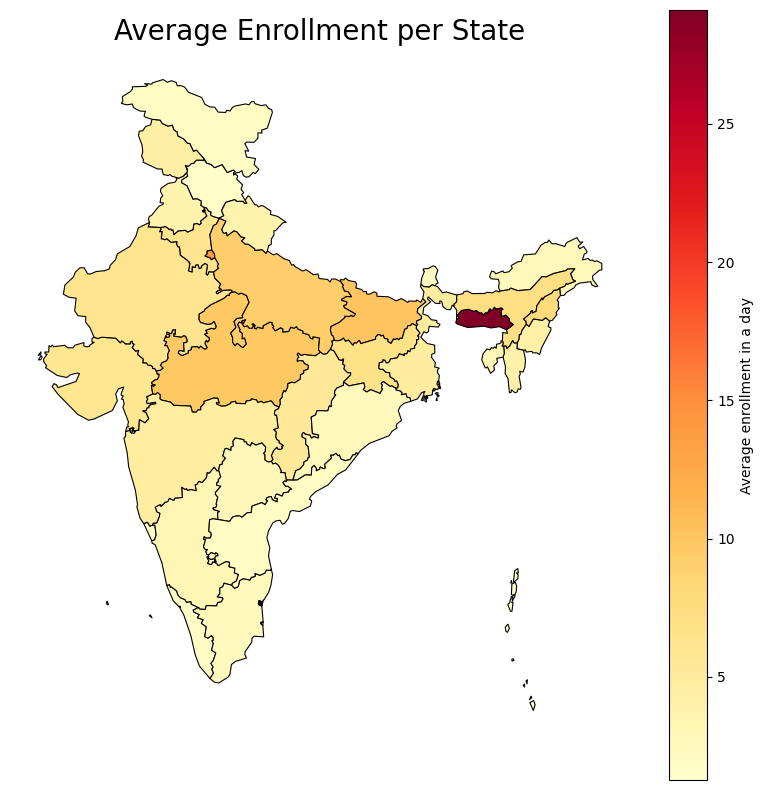

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.axis('off')
ax.set_title('Average Enrollment per State', fontdict={'fontsize': '20', 'fontweight' : '10'})
# Plot the figure
merged.plot(column='total_enrollement', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0', legend=True, legend_kwds={'label': "Average enrollment in a day"})
plt.savefig("heatmap_enrollment.svg")
plt.show()

In [29]:
print(avg_people_each_state)

state
Andaman and Nicobar Islands                  1.303571
Andhra Pradesh                               1.991528
Arunachal Pradesh                            2.713304
Assam                                        7.232758
Bihar                                       10.164572
Chandigarh                                   3.169965
Chhattisgarh                                 5.443529
Dadra and Nagar Haveli and Daman and Diu     4.324519
Delhi                                       13.893151
Goa                                          1.527832
Gujarat                                      6.017266
Haryana                                      6.141902
Himachal Pradesh                             1.690122
Jammu and Kashmir                            4.360808
Jharkhand                                    6.785210
Karnataka                                    3.180076
Kerala                                       1.916005
Ladakh                                       2.023881
Lakshadweep           

In [50]:
import json
import pandas as pd
import plotly.express as px

In [51]:
import plotly.io as pio
pio.renderers.default = 'colab'

In [52]:
indian_state = json.load(open('india_states.geojson', 'r'))

In [53]:
avg_people_each_state_df = avg_people_each_state.reset_index()
avg_people_each_state_df.columns = ['state', 'average_enrollment'] # Renaming columns for clarity
display(avg_people_each_state_df.head())

,state,average_enrollment
0,Andaman and Nicobar Islands,1.303571
1,Andhra Pradesh,1.991528
2,Arunachal Pradesh,2.713304
3,Assam,7.232758
4,Bihar,10.164572


In [54]:
total_peope_of_age_0_5= combined_df.groupby(['state'])['age_0_5'].sum()
count1= combined_df.groupby(['state'])['age_0_5'].count()

In [55]:
avg_people_of_age_0_5= total_peope_of_age_0_5/count1
avg_people_of_age_0_5 = avg_people_of_age_0_5.sort_values(ascending=False)

In [56]:
total_peope_of_age_5_17= combined_df.groupby(['state'])['age_5_17'].sum()
count2= combined_df.groupby(['state'])['age_5_17'].count()

In [57]:
avg_people_of_age_5_17 = total_peope_of_age_5_17/count2
avg_people_of_age_5_17 = avg_people_of_age_5_17.sort_values(ascending=False)

In [58]:
total_peope_of_age_18_greater= combined_df.groupby(['state'])['age_18_greater'].sum()
count3= combined_df.groupby(['state'])['age_18_greater'].count()

In [59]:
avg_people_of_age_18_greater= total_peope_of_age_18_greater/count3
avg_people_of_age_18_greater = avg_people_of_age_18_greater.sort_values(ascending=False)

C:\Users\kshit\AppData\Local\Temp\ipykernel_9984\3817303848.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kshit\AppData\Local\Temp\ipykernel_9984\3817303848.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kshit\AppData\Local\Temp\ipykernel_9984\3817303848.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


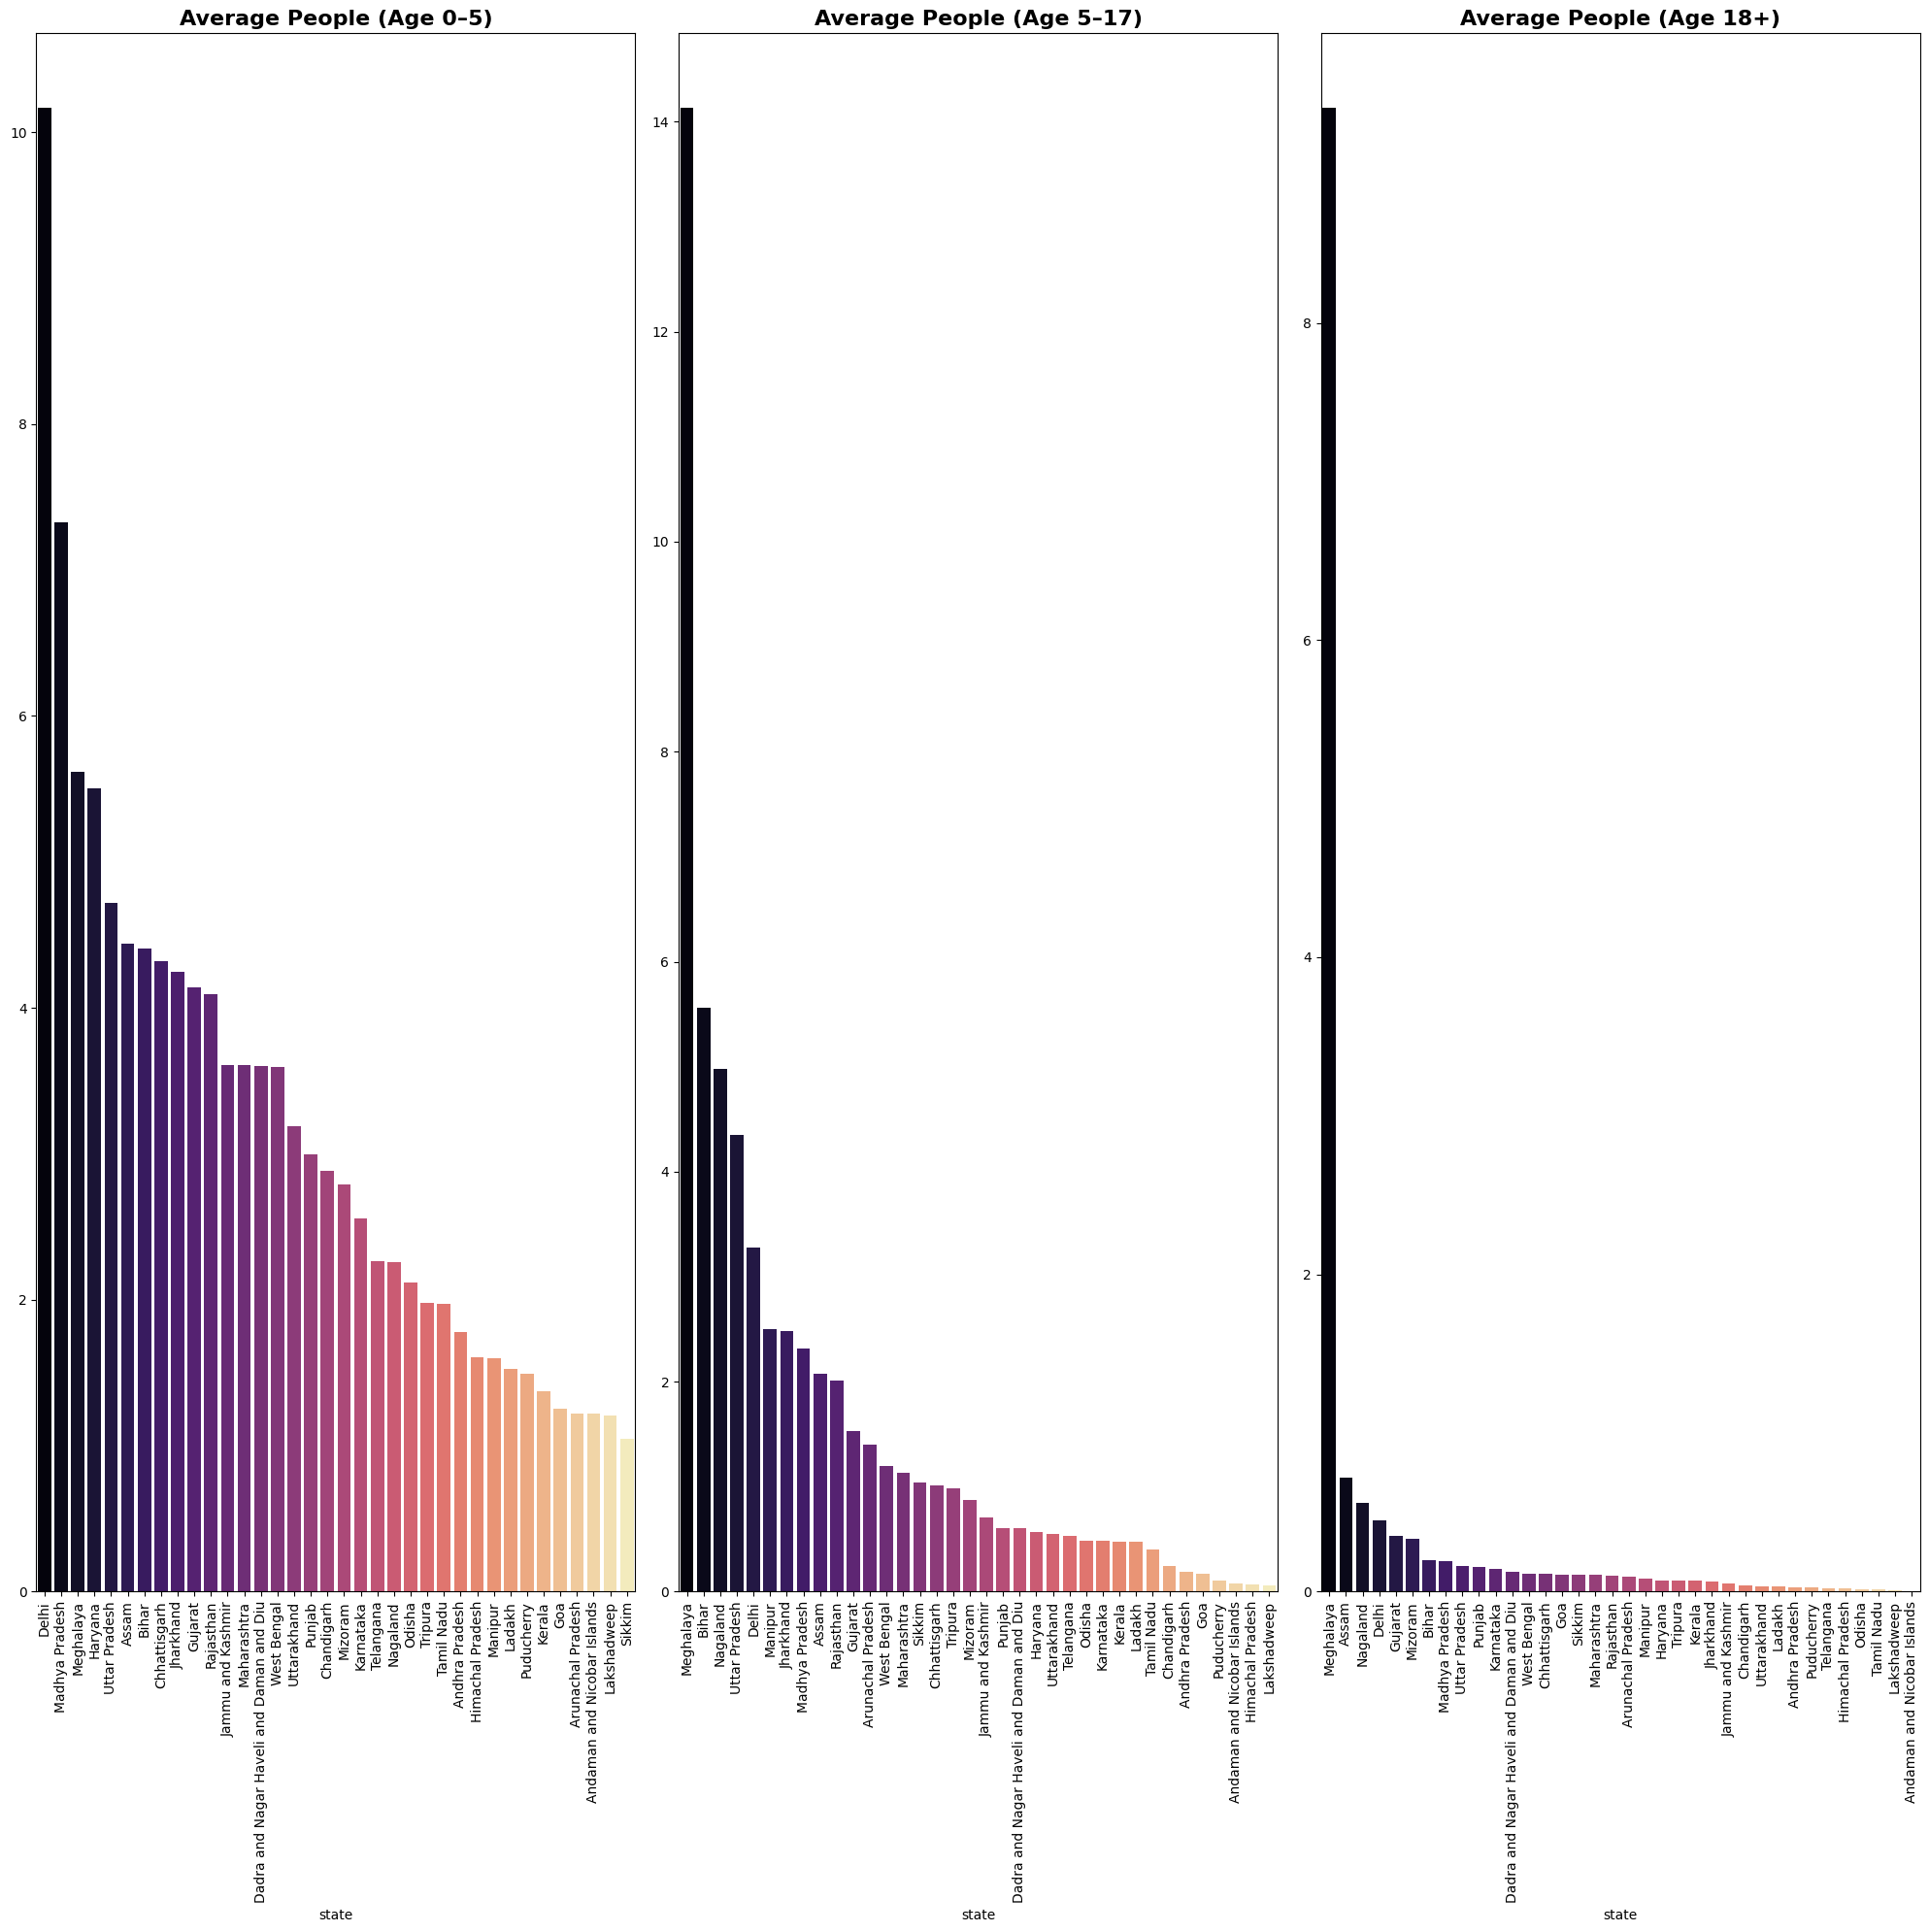

<Figure size 640x480 with 0 Axes>

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(20, 20))
fig.subplots_adjust(wspace=0.8)

age_data = [
    (avg_people_of_age_0_5, 'Average People (Age 0–5)'),
    (avg_people_of_age_5_17, 'Average People (Age 5–17)'),
    (avg_people_of_age_18_greater, 'Average People (Age 18+)')
]

for i, (d, title) in enumerate(age_data):
    sns.barplot(
        x=d.index,
        y=d.values,
        ax=ax[i],
        palette="magma"
    )
    ax[i].set_title(title, fontsize=16, fontweight='bold')
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
plt.savefig('map-svg')

In [61]:
combined_df.to_csv("downloaded_Enrollment_Combined_data.csv", index=False)